

<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">             <tr>
                <td  style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#025F5F"> <b>Deep Generative Models</b><br><br>Project 3 Score Based Modelss implementation </i></font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
           </tr>
</div>
        </table>
    </div>

## Mohammad Taha Majlesi - 8100101504

Deep Generative Models course - Dr. Tavassoli pour - University of Tehran


# **In the Name of God**  
## **University of Tehran**  
### **School of Electrical and Computer Engineering**  

---


### **Course Title: Deep Generative Models**  
**Instructor:** Dr. Mostafa Tavassoli  
**Homework 3**  
**Submission Date:** December 2023  

---




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

student_number = 810101504
np.random.seed(student_number)
torch.manual_seed(student_number)
if device.type == "cuda":
    torch.cuda.manual_seed_all(student_number)

Using device: cpu


## Imports and Configuration

This cell imports necessary libraries for the score-based generative model implementation, including PyTorch, NumPy, Matplotlib, and utilities. It also sets random seeds for reproducibility and configures the device (GPU if available).

In [ ]:
def generate_mixture_gaussians(n_samples=5000, train_split=0.8):
    w1 = 0.15 + np.random.rand() * 0.1
    w2 = 1 - w1

    if np.random.choice(2):
        mean1, mean2 = [-5, 5], [5, -5]
    else:
        mean1, mean2 = [5, 5], [-5, -5]

    if np.random.choice(2):
        w1, w2 = w2, w1

    var1 = 1 + np.random.rand()
    var2 = 1 + np.random.rand()

    cov1 = [[var1, 0], [0, var1]]
    cov2 = [[var2, 0], [0, var2]]

    n1 = int(n_samples * w1)
    n2 = n_samples - n1

    samples1 = np.random.multivariate_normal(mean1, cov1, n1)
    samples2 = np.random.multivariate_normal(mean2, cov2, n2)

    samples = np.vstack((samples1, samples2))

    indices = np.random.permutation(n_samples)
    train_samples = samples[indices[: int(n_samples * train_split)]]
    test_samples = samples[indices[int(n_samples * train_split) :]]

    params = {
        "w1": w1,
        "w2": w2,
        "mean1": mean1,
        "mean2": mean2,
        "cov1": cov1,
        "cov2": cov2,
    }

    return train_samples, test_samples, params


train_samples, test_samples, params = generate_mixture_gaussians()

## Data Generation

This cell defines a function to generate a mixture of 2D Gaussians as synthetic data for the score-based model. It creates train and test splits, computes the true probability density, and provides visualization functions for the data and score fields.

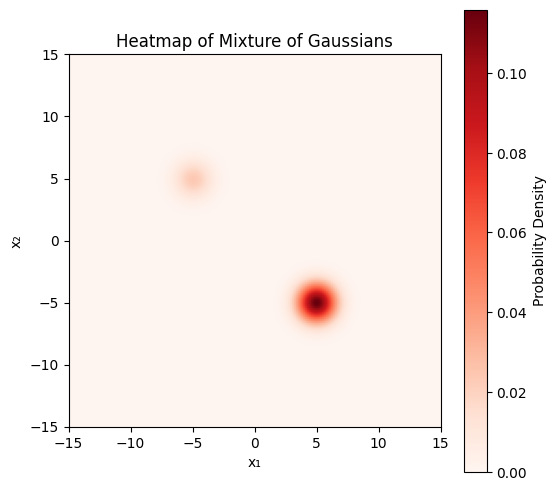

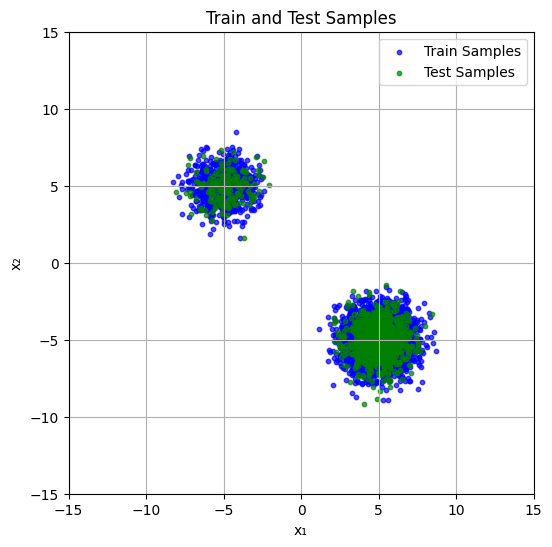

In [ ]:
x_min, x_max = -15, 15
y_min, y_max = -15, 15
grid_size = 200
x, y = np.meshgrid(
    np.linspace(x_min, x_max, grid_size), np.linspace(y_min, y_max, grid_size)
)
points_grid = np.stack([x, y], axis=-1).reshape(-1, 2)

extent = [x_min, x_max, y_min, y_max]


def gaussian_pdf(x, mean, cov):
    diff = x - mean
    inv_cov = np.linalg.inv(cov)
    det_cov = np.linalg.det(cov)
    norm_const = 1 / (2 * np.pi * np.sqrt(det_cov))
    exponent = -0.5 * np.sum(diff @ inv_cov * diff, axis=1)
    return norm_const * np.exp(exponent)


def p_x(points, params):
    pdf1 = params["w1"] * gaussian_pdf(points, params["mean1"], params["cov1"])
    pdf2 = params["w2"] * gaussian_pdf(points, params["mean2"], params["cov2"])
    return pdf1 + pdf2


z = p_x(points_grid, params).reshape(x.shape)


def plot_heatmap(z, extent, title="Heatmap of Mixture of Gaussians"):
    plt.figure(figsize=(6, 6))
    plt.imshow(z, extent=extent, origin="lower", cmap="Reds")
    plt.title(title)
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.colorbar(label="Probability Density")
    plt.show()


def plot_train_test_samples(
    train_samples, test_samples, extent, title="Train and Test Samples"
):
    plt.figure(figsize=(6, 6))
    plt.scatter(
        train_samples[:, 0],
        train_samples[:, 1],
        s=10,
        alpha=0.7,
        label="Train Samples",
        color="blue",
    )
    plt.scatter(
        test_samples[:, 0],
        test_samples[:, 1],
        s=10,
        alpha=0.7,
        label="Test Samples",
        color="green",
    )
    plt.xlim(extent[0], extent[1])
    plt.ylim(extent[2], extent[3])
    plt.title(title)
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_heatmap(z, extent=extent)

plot_train_test_samples(
    train_samples, test_samples, extent=extent, title="Train and Test Samples"
)

## Data Visualization

This cell visualizes the generated mixture of Gaussians data, showing the probability density heatmap and scatter plots of train/test samples.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt


def plot_score_field_individual(model, params, extent, sigma_values, save_plots=False):

    for sigma in sigma_values:
        print(f"Plotting score field for sigma={sigma}")
        plt.figure(figsize=(6, 6))
        plt.imshow(z, extent=extent, origin="lower", cmap="Reds", alpha=0.7)
        plt.title(f"Score Field at Sigma={sigma}")
        ax = plt.gca()

        x_vals = np.linspace(x_min, x_max, 15)
        y_vals = np.linspace(y_min, y_max, 15)
        X, Y = np.meshgrid(x_vals, y_vals)
        points = np.stack([X, Y], axis=-1).reshape(-1, 2)

        points_tensor = torch.tensor(points, dtype=torch.float32)
        sigma_tensor = torch.tensor(
            np.full((points.shape[0], 1), sigma), dtype=torch.float32
        )

        scores = model(points_tensor, sigma_tensor)

        U = scores[:, 0].detach().numpy().reshape(X.shape)
        V = scores[:, 1].detach().numpy().reshape(Y.shape)

        magnitude = np.sqrt(U**2 + V**2)
        scale_factor = 1 / (magnitude + 1e-8)
        U_scaled = U * scale_factor
        V_scaled = V * scale_factor

        U_norm = U_scaled / (np.sqrt(U_scaled**2 + V_scaled**2) + 1e-8)
        V_norm = V_scaled / (np.sqrt(U_scaled**2 + V_scaled**2) + 1e-8)

        ax.quiver(X, Y, U_norm, V_norm, color="black", pivot="middle")

        plt.colorbar(label="Probability Density")
        plt.xlabel("X₁")
        plt.ylabel("X₂")
        plt.grid(True)

        if save_plots:
            filename = f"score_field_sigma_{sigma}.png"
            plt.savefig(f"./{filename}")
            print(f"Saved plot: {filename}")

        plt.show()

## Score Field Visualization

This cell defines a function to visualize the learned score field (gradient of log-density) at different noise levels (sigma values), overlaying it on the true data distribution.

In [ ]:
def add_noise(x, sigma):
    epsilon = torch.randn_like(x) * sigma.expand_as(x)
    x_noisy = x + epsilon
    return x_noisy, epsilon


def score_matching_loss(x, x_noisy, epsilon, sigma, outputs):

    term = outputs + epsilon / (sigma**2)
    loss = 0.5 * torch.mean((term) ** 2)
    return loss

## Noise Addition and Loss Function

This cell defines functions to add noise to data and compute the score matching loss, which trains the model to predict the score (gradient of log-density) at different noise levels.

In [ ]:

class ScoreNet(nn.Module):

    def __init__(self, input_dim=3, hidden_dim=256, num_layers=6):

        super(ScoreNet, self).__init__()
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.BatchNorm1d(hidden_dim))
        layers.append(nn.LeakyReLU())

        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.LeakyReLU())

        layers.append(nn.Linear(hidden_dim, 2))

        self.net = nn.Sequential(*layers)

    def forward(self, x, sigma):
        x_sigma = torch.cat([x, sigma], dim=1)
        return self.net(x_sigma)


## Score Network Architecture

This cell defines the ScoreNet neural network, a multi-layer perceptron that takes noisy data and noise level as input to predict the score function for score-based generative modeling.

In [ ]:
def train_score_model(
    model,
    data_loader,
    sigma_schedule=None,
    epochs=1000,
    learning_rate=0.001,
    scheduler_step=500,
    scheduler_gamma=0.5,
    clip_grad=None,
    patience=200,
    fixed_sigma=None,
):

    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.StepLR(
        optimizer, step_size=scheduler_step, gamma=scheduler_gamma
    )
    loss_history = []

    best_loss = float("inf")
    epochs_no_improve = 0

    for epoch_num in tqdm(range(1, epochs + 1), desc="Training Progress"):
        epoch_loss = 0.0

        model.train()
        for batch in data_loader:
            x_batch = batch[0].to(device)
            batch_size = x_batch.shape[0]

            if fixed_sigma is not None:
                sigma = torch.ones(batch_size, 1, device=device) * fixed_sigma
            else:
                sigma = torch.randint(
                    low=1, high=20, size=(batch_size, 1), device=device
                )

            x_noisy, epsilon = add_noise(x_batch, sigma)

            outputs = model(x_noisy, sigma)

            loss = score_matching_loss(x_batch, x_noisy, epsilon, sigma, outputs)

            optimizer.zero_grad()
            loss.backward()
            if clip_grad:
                nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()

            epoch_loss += loss.item() * batch_size

        scheduler.step()
        avg_train_loss = epoch_loss / len(data_loader.dataset)
        loss_history.append(avg_train_loss)

        if avg_train_loss < best_loss:
            best_loss = avg_train_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), "best_score_model.pth")
        else:
            epochs_no_improve += 1

        if epoch_num % 100 == 0 or epoch_num == 1:

            current_sigma = sigma

            print(f"Epoch {epoch_num}/{epochs}, Loss: {avg_train_loss:.6f}")
            perform_sampling_and_plot(model, epoch_num, num_points=1000)

    try:
        model.load_state_dict(torch.load("best_score_model.pth"))
    except RuntimeError:
        model.load_state_dict(torch.load("best_score_model.pth", map_location=device))

    return model, loss_history

## Training Function

This cell defines the training loop for the score network, including early stopping, learning rate scheduling, and periodic sampling and plotting to monitor progress.

In [ ]:
def annealed_sampling(
    model,
    start_points,
    sigma_start=20,
    sigma_end=1,
    steps_per_sigma=50,
    num_sigmas=20,
    step_size=0.1,
):

    current = start_points.clone().to(device)
    sigma_values = np.linspace(sigma_start, sigma_end, num_sigmas)
    samples_at_each_sigma = []

    with torch.no_grad():
        for si in sigma_values:
            sigma_t = torch.ones(current.shape[0], 1, device=device) * si
            for _ in range(steps_per_sigma):
                grad = model(current, sigma_t)
                noise = torch.randn_like(current) * np.sqrt(0.1 * step_size) * si
                current = current + step_size * grad + noise
            samples_at_each_sigma.append(current.clone().cpu().numpy())

    return current.cpu().numpy(), samples_at_each_sigma, sigma_values


def langevin_sampling(model, start_points, num_steps=50, step_size=0.1):
    current_points = start_points.to(device).detach()
    trajectory = [current_points]
    with torch.no_grad():
        for _ in range(num_steps):
            sigma_val = torch.ones(current_points.shape[0], 1, device=device)
            grad = model(current_points, sigma_val)
            noise = torch.randn_like(current_points) * np.sqrt(0.1 * step_size)
            current_points = current_points + step_size * grad + noise
            trajectory.append(current_points)
    return trajectory


def deterministic_sampling(model, start_points, num_steps=50, step_size=0.1):
    current_points = start_points.to(device).detach()
    trajectory = [current_points]
    with torch.no_grad():
        for _ in range(num_steps):
            sigma_val = torch.ones(current_points.shape[0], 1, device=device)
            grad = model(current_points, sigma_val)
            current_points = current_points + step_size * grad
            trajectory.append(current_points)
    return trajectory

## Sampling Methods

This cell implements various sampling methods for score-based models: annealed Langevin dynamics, standard Langevin dynamics, and deterministic sampling using the learned score function.

In [ ]:
def plot_sampling_results(
    annealed_samples,
    langevin_samples,
    deterministic_samples,
    test_samples,
    extent,
    epoch,
):

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.scatter(
        test_samples[:, 0],
        test_samples[:, 1],
        s=10,
        alpha=0.3,
        label="Test Samples",
        color="green",
    )
    plt.scatter(
        annealed_samples[:, 0],
        annealed_samples[:, 1],
        s=10,
        alpha=0.3,
        label="Annealed Samples",
        color="purple",
    )
    plt.title(f"Annealed Sampling at Epoch {epoch}")
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.scatter(
        test_samples[:, 0],
        test_samples[:, 1],
        s=10,
        alpha=0.3,
        label="Test Samples",
        color="green",
    )
    plt.scatter(
        langevin_samples[:, 0],
        langevin_samples[:, 1],
        s=10,
        alpha=0.3,
        label="Langevin Samples",
        color="orange",
    )
    plt.title(f"Langevin Sampling at Epoch {epoch}")
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.scatter(
        test_samples[:, 0],
        test_samples[:, 1],
        s=10,
        alpha=0.3,
        label="Test Samples",
        color="green",
    )
    plt.scatter(
        deterministic_samples[:, 0],
        deterministic_samples[:, 1],
        s=10,
        alpha=0.3,
        label="Deterministic Samples",
        color="cyan",
    )
    plt.title(f"Deterministic Sampling at Epoch {epoch}")
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


def plot_sampling_trajectories_with_start_points(
    start_points, deterministic_traj, langevin_traj, z, extent, grid_spacing=5
):

    deterministic_traj = np.concatenate(
        [traj.cpu().numpy() for traj in deterministic_traj], axis=0
    )
    langevin_traj = np.concatenate(
        [traj.cpu().numpy() for traj in langevin_traj], axis=0
    )

    plt.figure(figsize=(10, 10))
    plt.imshow(z, extent=extent, origin="lower", cmap="Reds", alpha=0.3)

    plt.scatter(
        start_points[:, 0],
        start_points[:, 1],
        s=50,
        c="red",
        label="Starting Points",
        zorder=5,
    )

    plt.plot(
        deterministic_traj[:, 0],
        deterministic_traj[:, 1],
        marker="o",
        color="blue",
        alpha=0.6,
        label="Deterministic Sampling",
    )
    for i in range(0, len(deterministic_traj), grid_spacing):
        plt.annotate(
            f"{i}",
            (deterministic_traj[i, 0], deterministic_traj[i, 1]),
            textcoords="offset points",
            xytext=(5, 5),
            ha="center",
            color="blue",
            fontsize=9,
        )

    plt.plot(
        langevin_traj[:, 0],
        langevin_traj[:, 1],
        marker="o",
        color="green",
        alpha=0.6,
        label="Langevin Sampling",
    )
    for i in range(0, len(langevin_traj), grid_spacing):
        plt.annotate(
            f"{i}",
            (langevin_traj[i, 0], langevin_traj[i, 1]),
            textcoords="offset points",
            xytext=(-5, -5),
            ha="center",
            color="green",
            fontsize=9,
        )

    plt.colorbar(label="Probability Density")
    plt.xlabel("X₁")
    plt.ylabel("X₂")
    plt.title("Sampling Trajectories with Starting Points")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_annealed_sampling_steps(
    annealed_traj, z, extent, x_min, x_max, y_min, y_max, epoch
):
    plt.figure(figsize=(8, 8))
    plt.imshow(z, extent=extent, origin="lower", cmap="Reds", alpha=0.3)
    for idx, sample in enumerate(annealed_traj):
        if idx % 10 == 0 or idx == len(annealed_traj) - 1:
            plt.scatter(
                sample[:, 0],
                sample[:, 1],
                s=10,
                alpha=0.2,
                label=f"Step {idx + 1}" if idx == 0 else "",
            )
    plt.title(f"Annealed Sampling Steps at Epoch {epoch}")
    plt.xlabel("X₁")
    plt.ylabel("X₂")
    plt.legend()
    plt.grid(True)
    plt.xlim([x_min, x_max])
    plt.ylim([y_min, y_max])
    plt.show()

## Sampling Visualization

This cell defines functions to visualize sampling results, including comparison plots of different sampling methods and trajectory plots showing the evolution of samples during generation.

In [ ]:
def perform_sampling_and_plot(model, epoch, num_points=1000):
    model.eval()
    with torch.no_grad():

        num_steps = 50
        step_size = 0.1
        start_points = (torch.rand(num_points, 2) * (x_max - x_min) + x_min).to(device)

        langevin_traj = langevin_sampling(model, start_points, num_steps, step_size)
        langevin_final = langevin_traj[-1].cpu().numpy()

        annealed_final, annealed_traj, annealed_sigma = annealed_sampling(
            model,
            start_points,
            sigma_start=20,
            sigma_end=1,
            steps_per_sigma=50,
            num_sigmas=20,
            step_size=step_size,
        )

        deterministic_traj = deterministic_sampling(
            model, start_points, num_steps, step_size
        )
        deterministic_final = deterministic_traj[-1].cpu().numpy()
        plot_sampling_results(
            annealed_final,
            langevin_final,
            deterministic_final,
            test_samples,
            extent,
            epoch,
        )

## Sampling Execution

This cell defines a function to perform sampling using different methods and visualize the results at each training epoch.


--- Phase 1: Training with Fixed Sigma=1 ---

Training ScoreNet with fixed sigma=1...


Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100, Loss: 0.330585


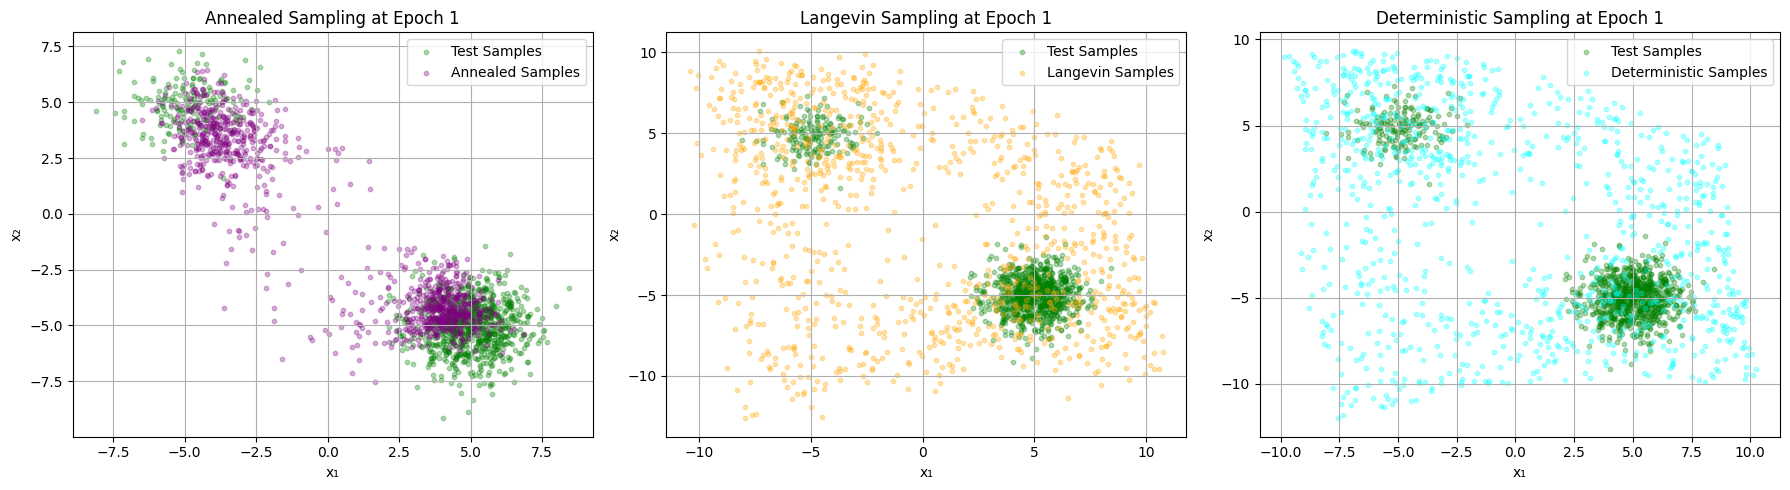

Training Progress:  99%|█████████▉| 99/100 [01:27<00:01,  1.10s/it]

Epoch 100/100, Loss: 0.268810


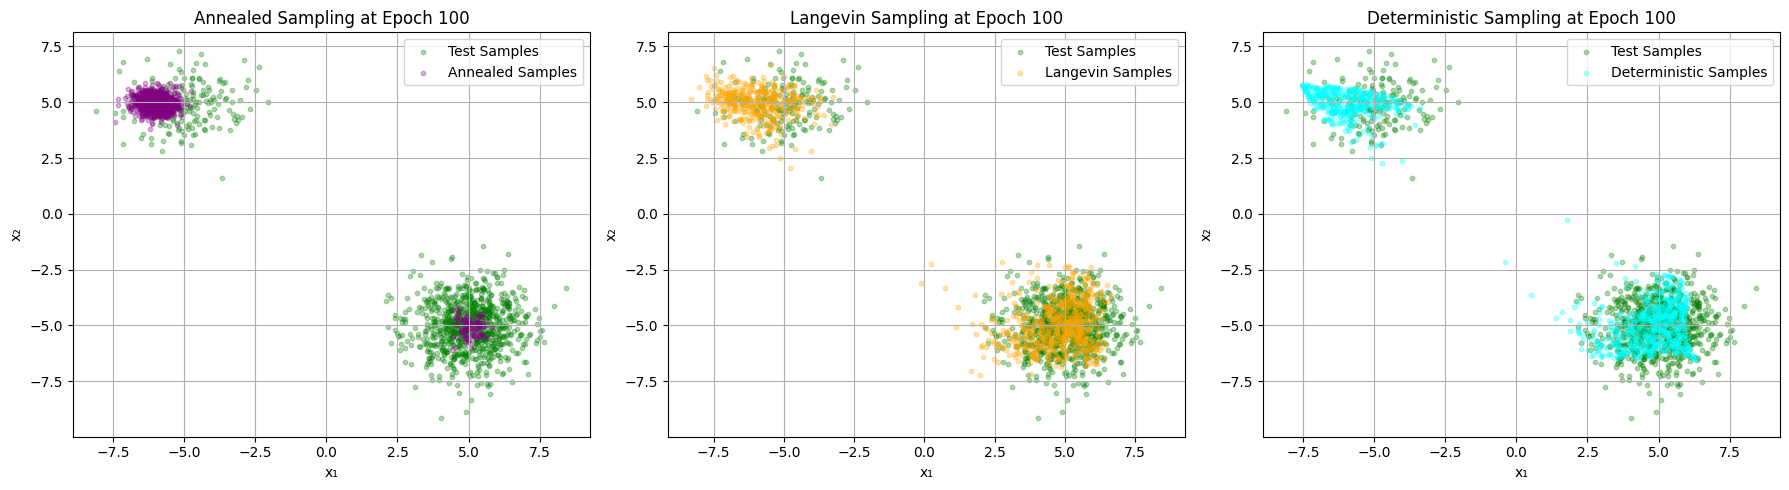

Training Progress: 100%|██████████| 100/100 [01:43<00:00,  1.03s/it]
<ipython-input-62-368586b7eaec>:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(

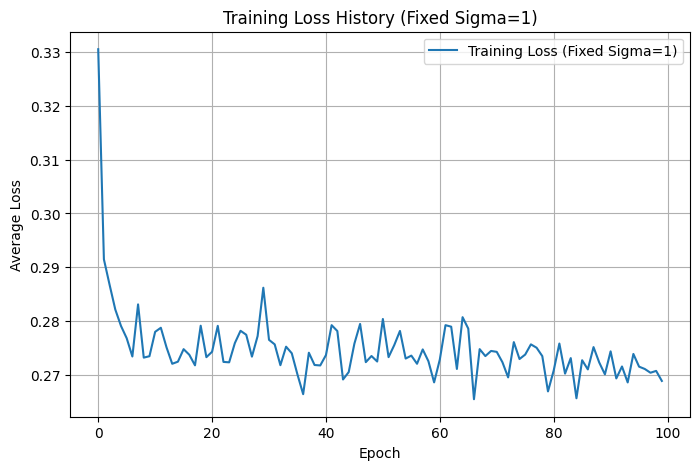


Visualizing score fields for Sigma=1...
Plotting score field for sigma=1


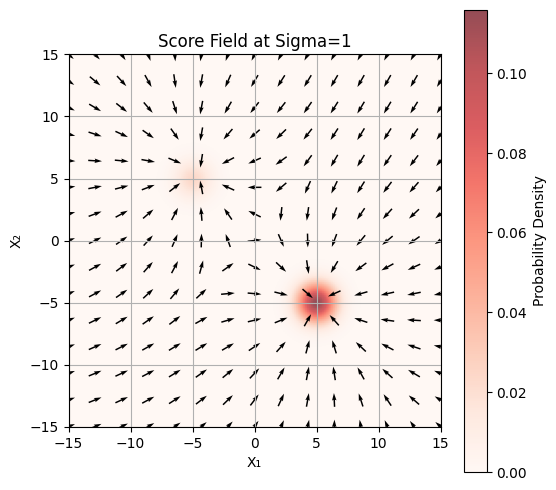


Performing sampling with fixed sigma=1...


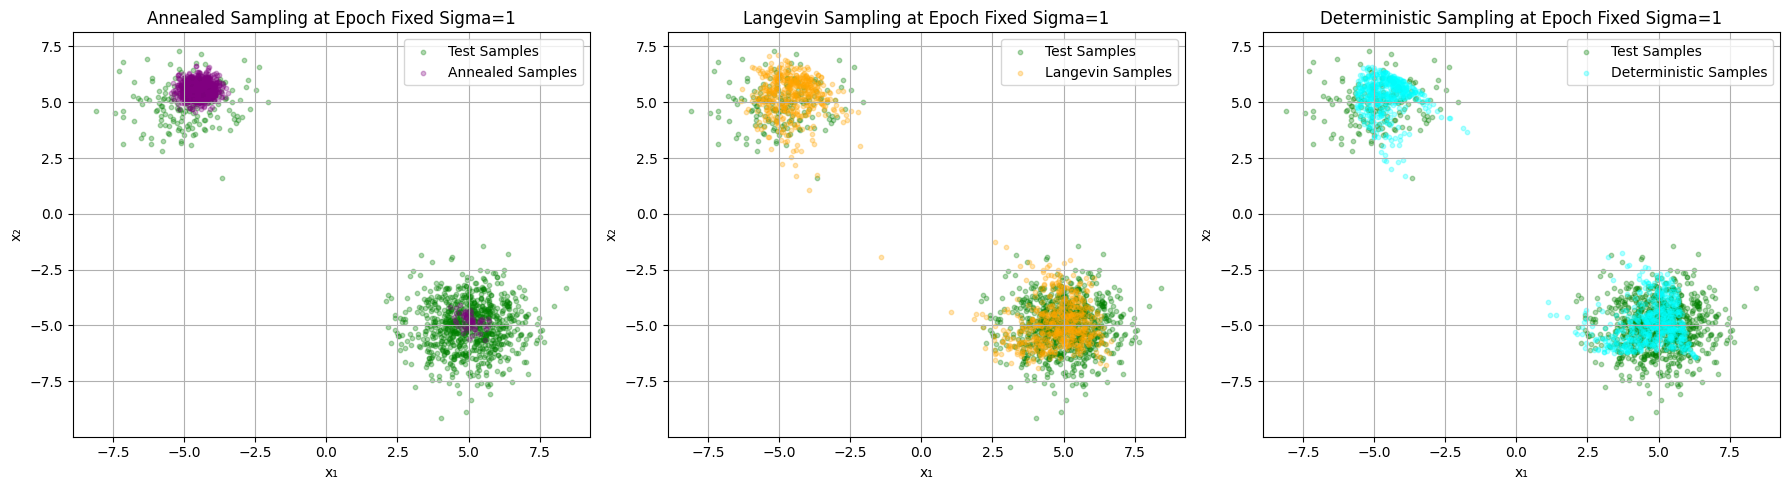


--- Phase 1: Training with Fixed Sigma=3 ---

Training ScoreNet with fixed sigma=3...


Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100, Loss: 0.045335


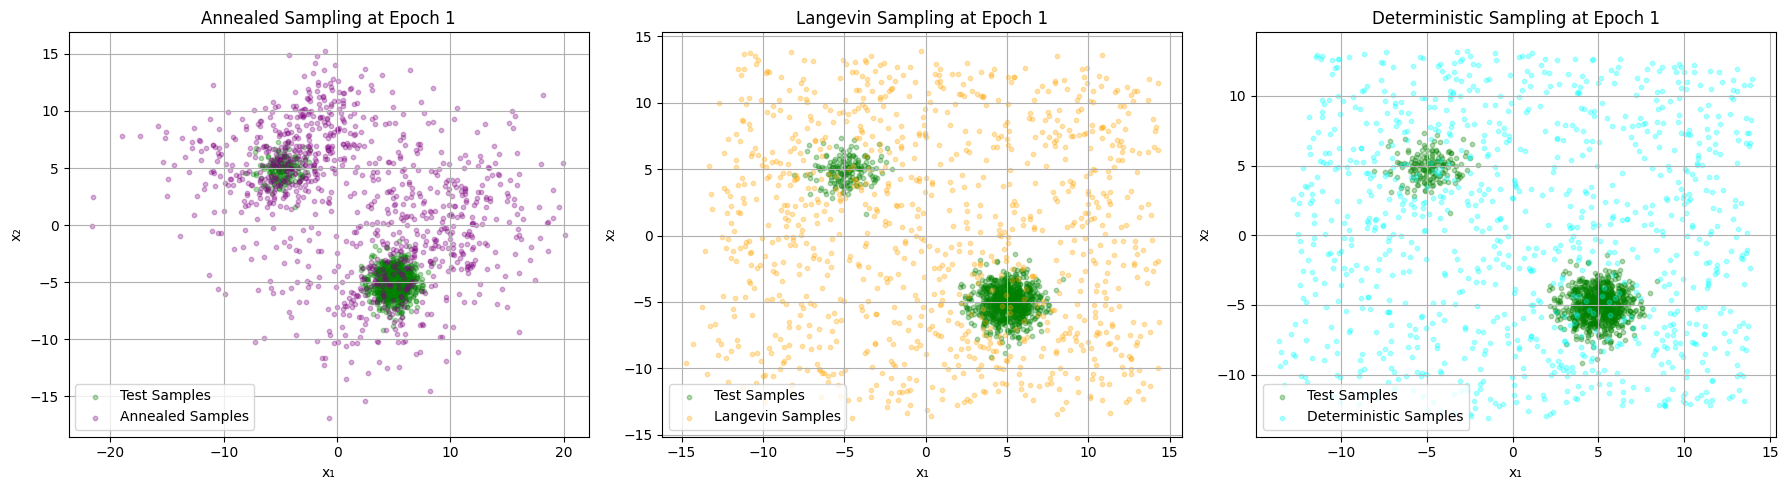

Training Progress:  99%|█████████▉| 99/100 [01:19<00:00,  1.46it/s]

Epoch 100/100, Loss: 0.011861


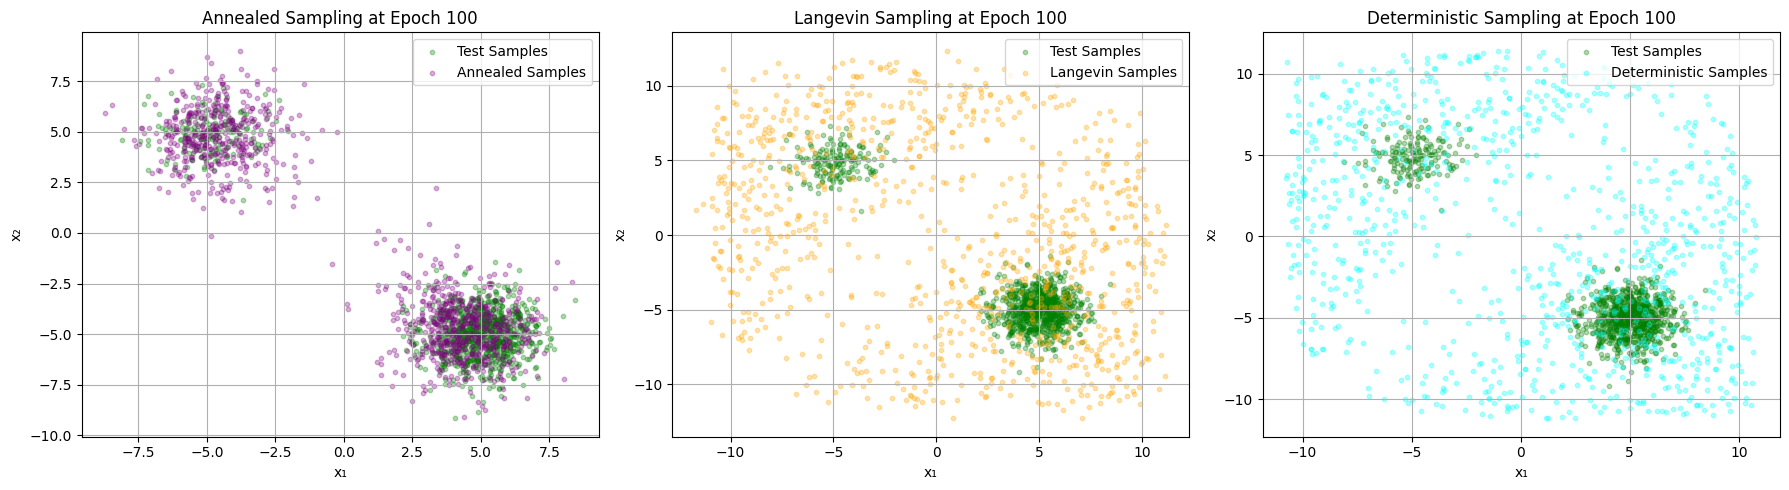

Training Progress: 100%|██████████| 100/100 [01:34<00:00,  1.06it/s]


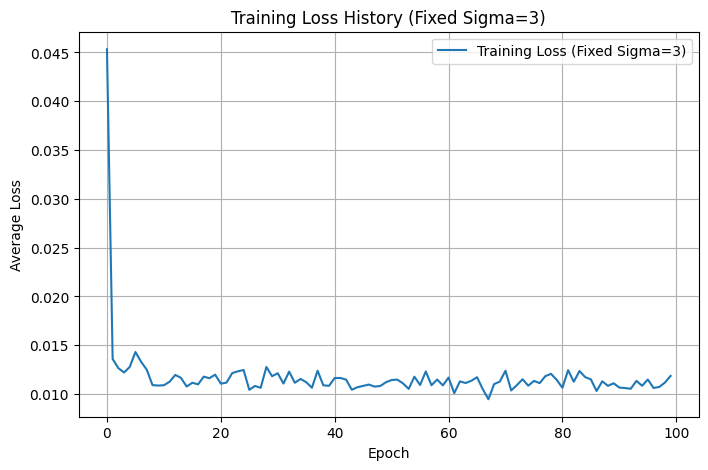


Visualizing score fields for Sigma=3...
Plotting score field for sigma=3


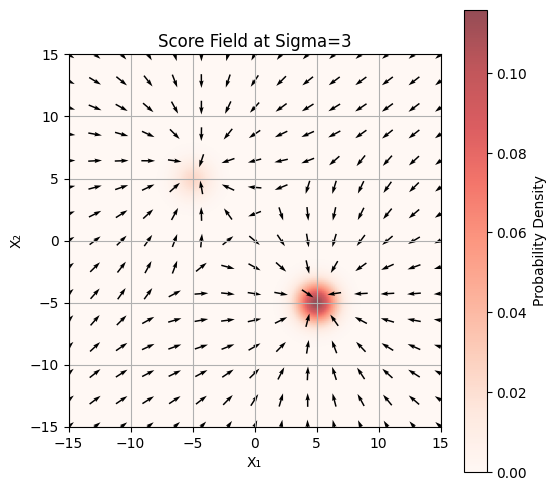


Performing sampling with fixed sigma=3...


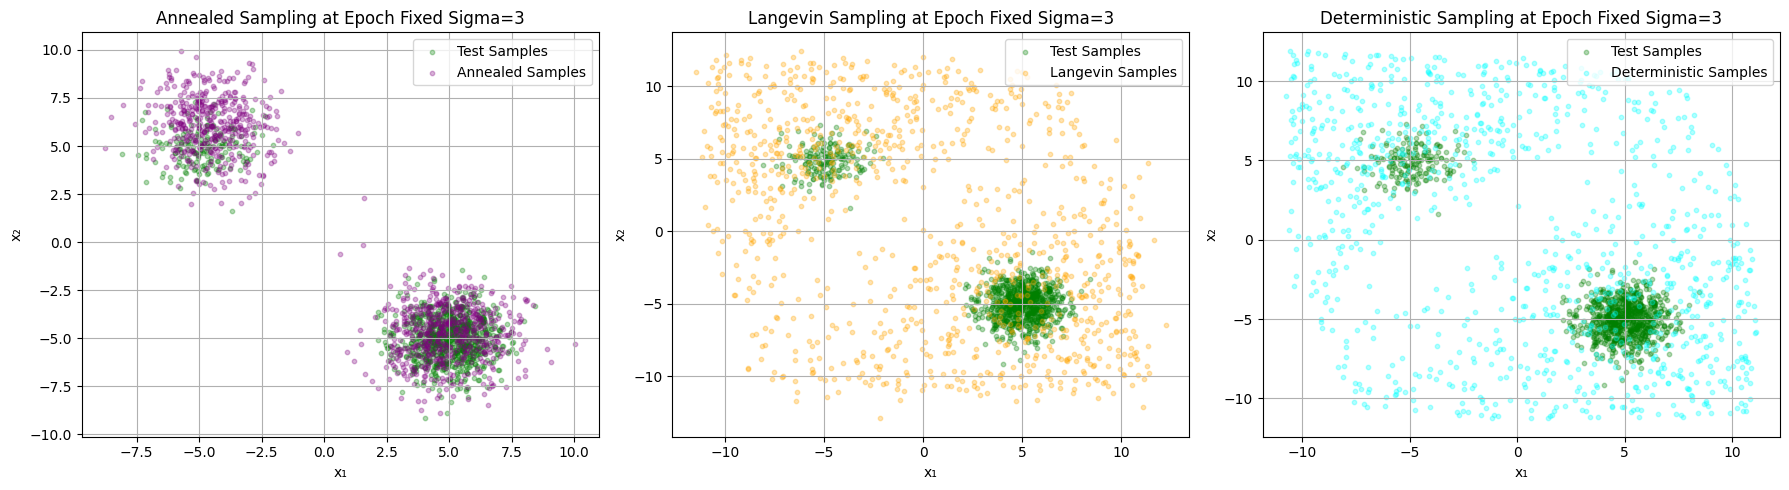


--- Phase 1: Training with Fixed Sigma=7 ---

Training ScoreNet with fixed sigma=7...


Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100, Loss: 0.040102


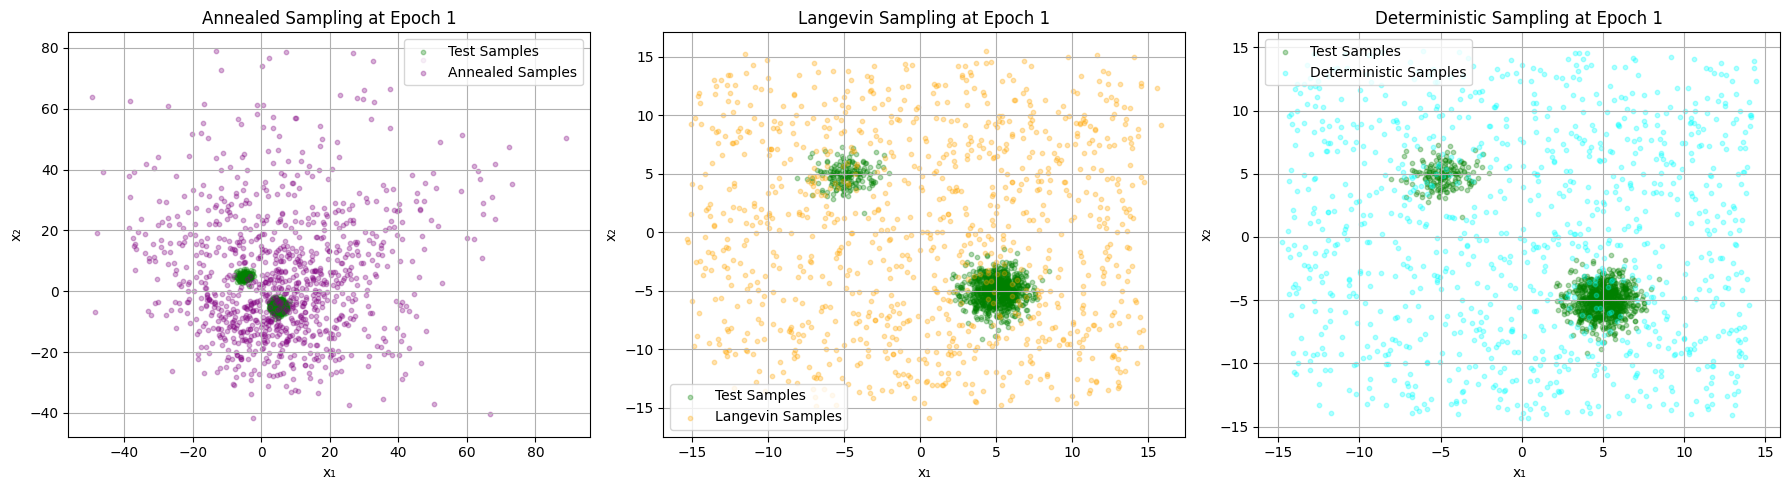

Training Progress:  99%|█████████▉| 99/100 [01:19<00:00,  1.53it/s]

Epoch 100/100, Loss: 0.002063


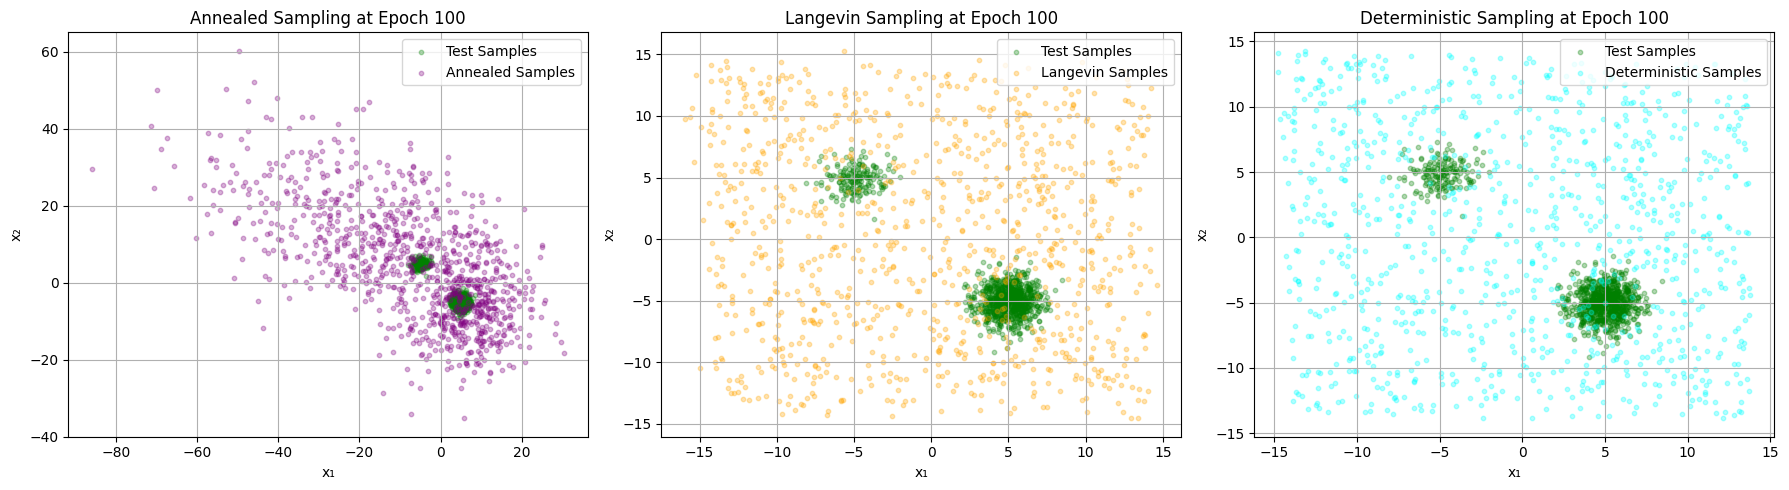

Training Progress: 100%|██████████| 100/100 [01:34<00:00,  1.06it/s]


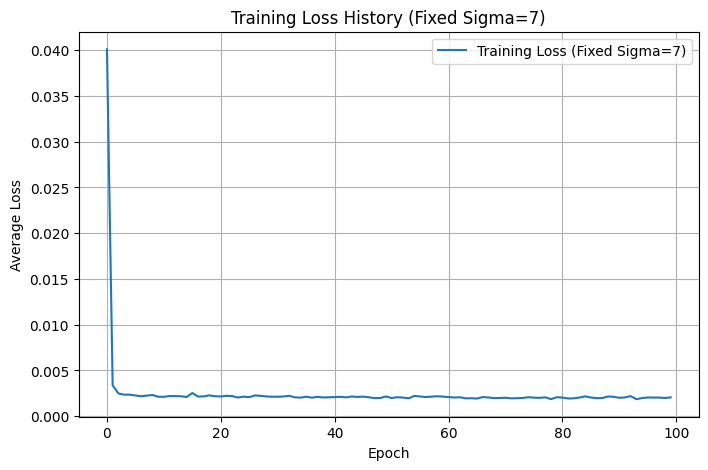


Visualizing score fields for Sigma=7...
Plotting score field for sigma=7


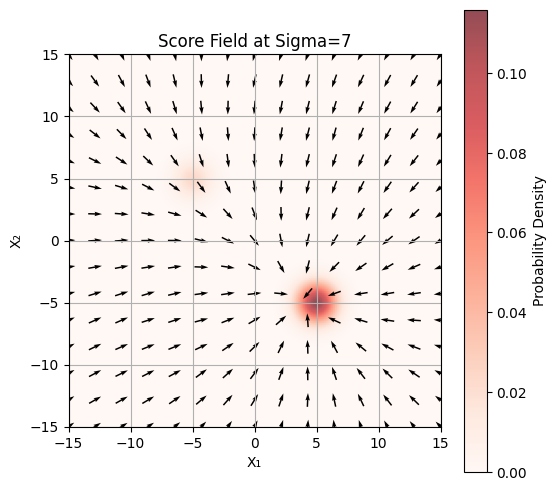


Performing sampling with fixed sigma=7...


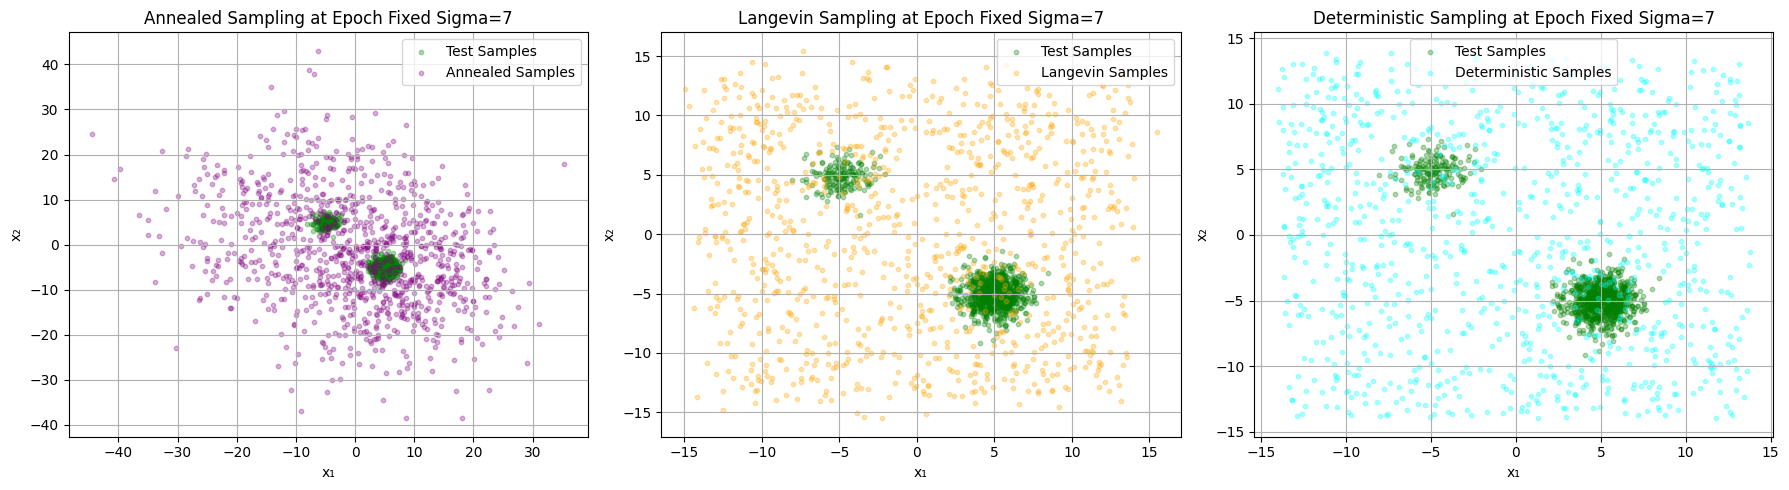

In [ ]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

sigma_values = [1, 3, 7]
models = {}
loss_histories = {}

for sigma in sigma_values:
    print(f"\n--- Phase 1: Training with Fixed Sigma={sigma} ---\n")

    model = ScoreNet(input_dim=3, hidden_dim=256, num_layers=6)
    print(f"Training ScoreNet with fixed sigma={sigma}...")

    train_data = torch.tensor(train_samples).float()
    dataset = TensorDataset(train_data)
    data_loader = DataLoader(dataset, batch_size=256, shuffle=True, num_workers=2)

    model, loss_history = train_score_model(
        model,
        data_loader,
        sigma_schedule=None,
        epochs=100,
        learning_rate=0.001,
        scheduler_step=100,
        scheduler_gamma=0.5,
        clip_grad=1.0,
        patience=100,
        fixed_sigma=sigma,
    )

    models[sigma] = model
    loss_histories[sigma] = loss_history

    plt.figure(figsize=(8, 5))
    plt.plot(loss_history, label=f"Training Loss (Fixed Sigma={sigma})")
    plt.xlabel("Epoch")
    plt.ylabel("Average Loss")
    plt.title(f"Training Loss History (Fixed Sigma={sigma})")
    plt.grid(True)
    plt.legend()
    plt.show()

    print(f"\nVisualizing score fields for Sigma={sigma}...")
    plot_score_field_individual(
        model, params, extent=extent, sigma_values=[sigma], save_plots=False
    )

    print(f"\nPerforming sampling with fixed sigma={sigma}...")
    perform_sampling_and_plot(model, epoch=f"Fixed Sigma={sigma}", num_points=1000)

## Fixed Sigma Training Experiments

This cell trains score networks with fixed noise levels (sigma values) and evaluates their performance through loss curves and score field visualizations.

Training ScoreNet with fixed sigma=1...


Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100, Loss: 0.327940


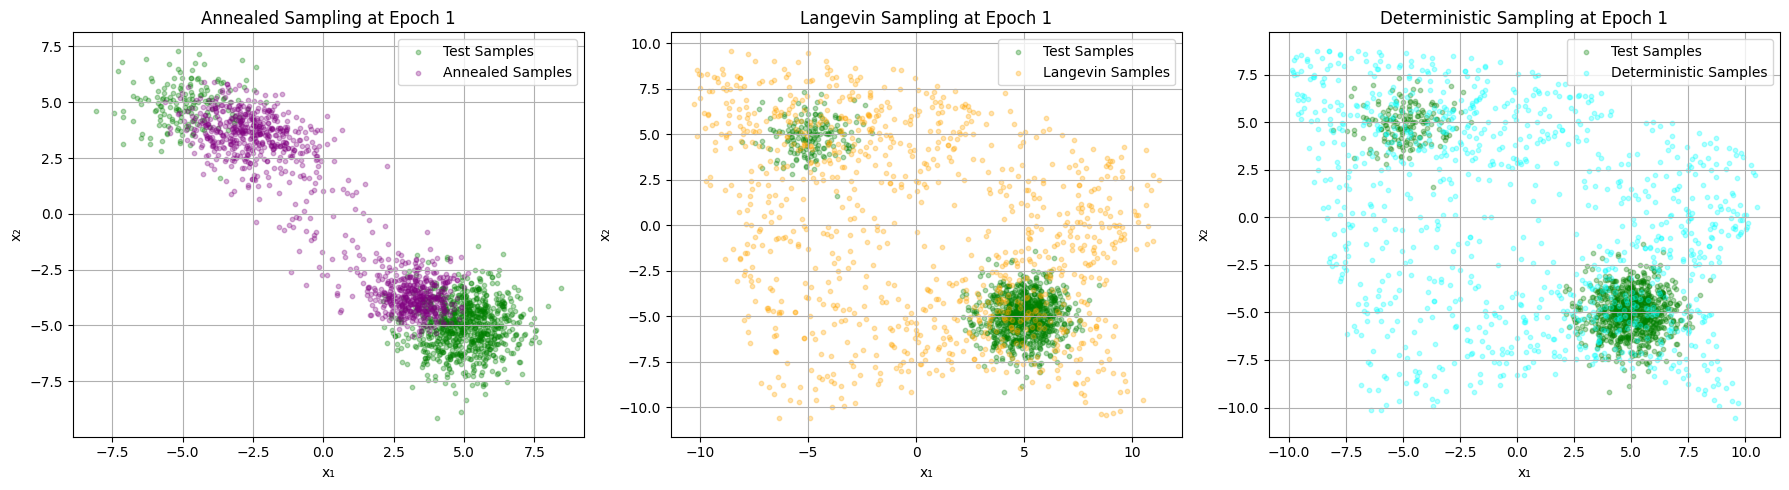

Training Progress:  99%|█████████▉| 99/100 [01:22<00:00,  1.50it/s]

Epoch 100/100, Loss: 0.272318


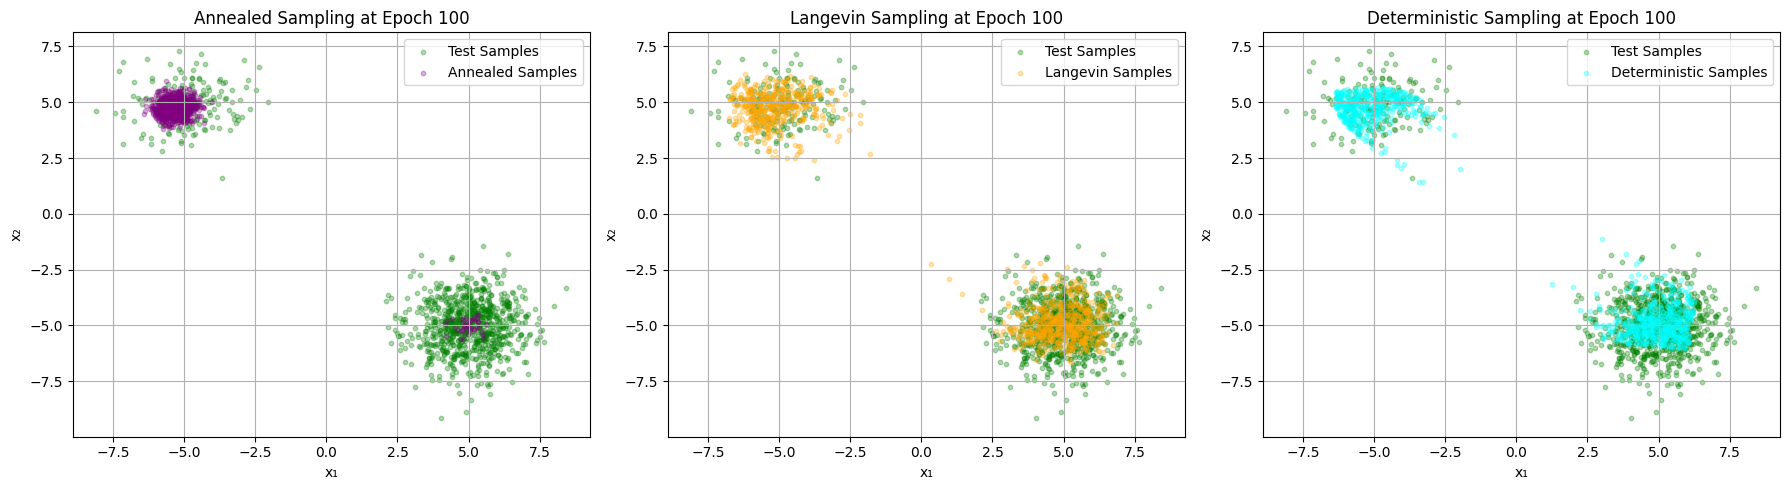

Training Progress: 100%|██████████| 100/100 [01:37<00:00,  1.02it/s]
<ipython-input-62-368586b7eaec>:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(


Visualizing Trajectories for Start Point: [10 20]


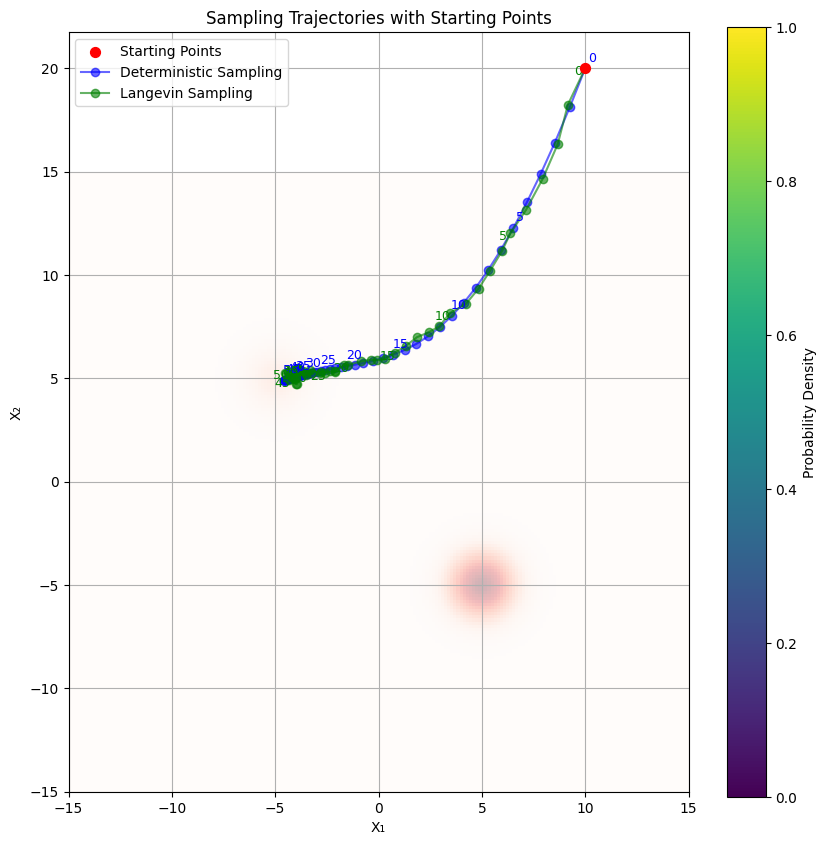


Visualizing Trajectories for Start Point: [-10 -20]


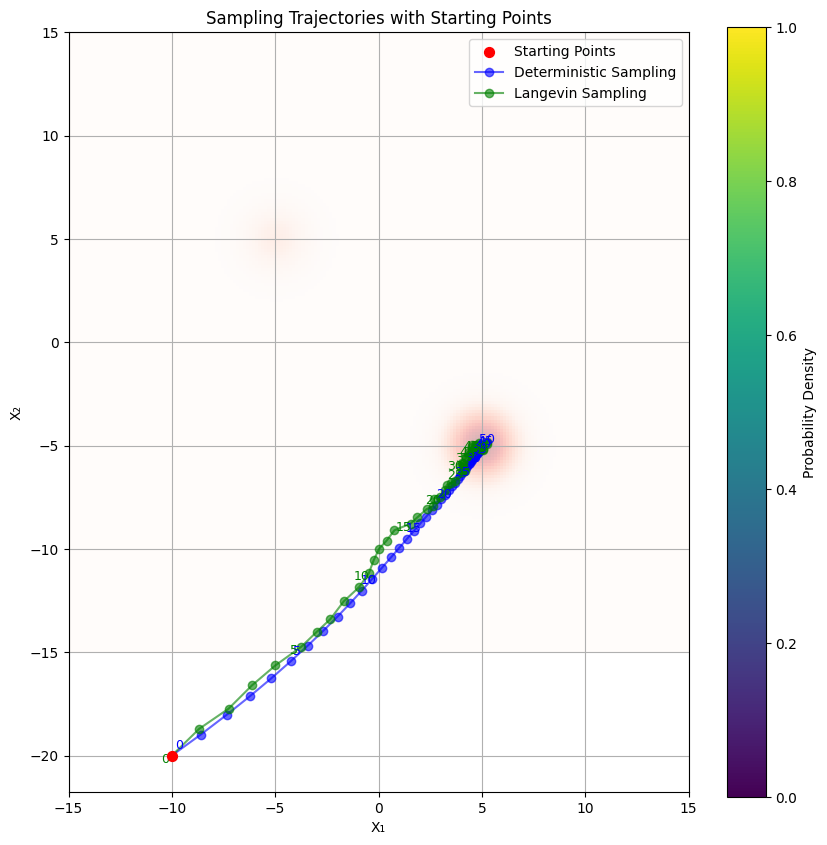


Visualizing Trajectories for Start Point: [5 5]


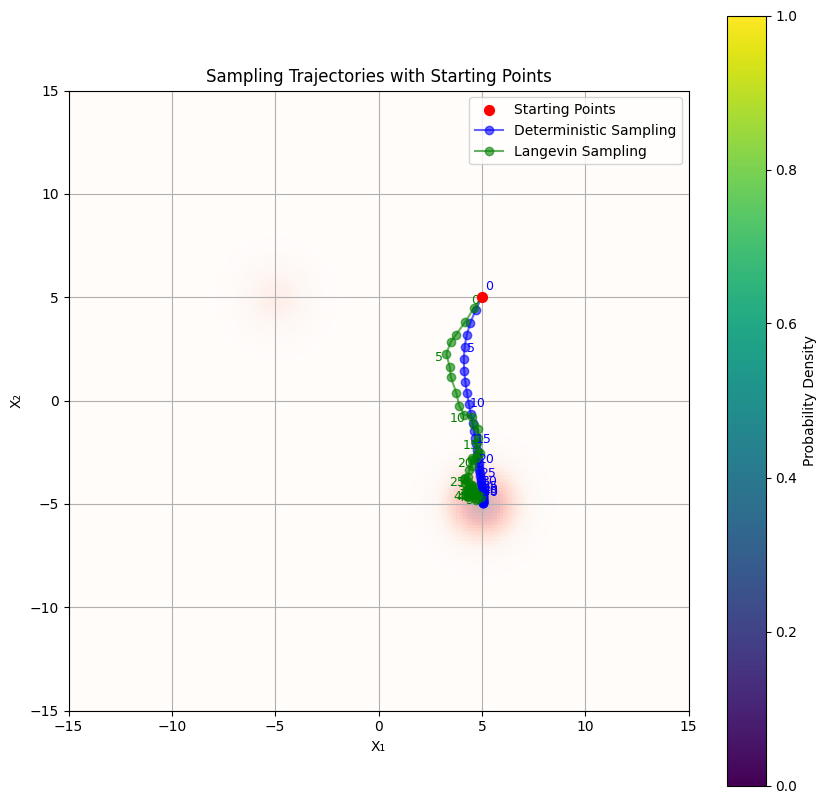


Visualizing Trajectories for Start Point: [-5 -5]


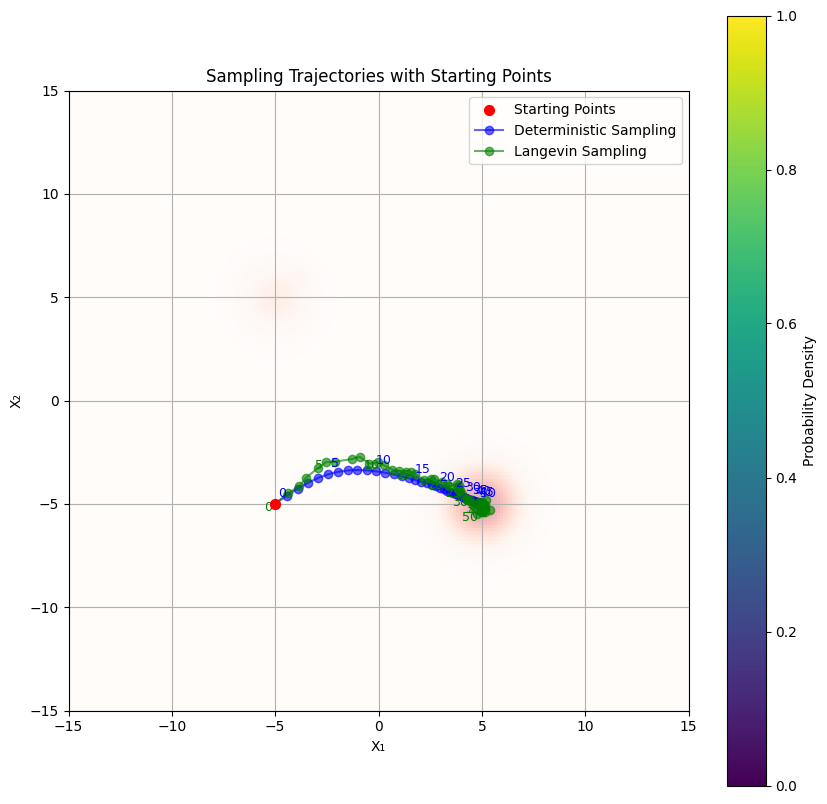


Visualizing Trajectories for Start Point: [0 0]


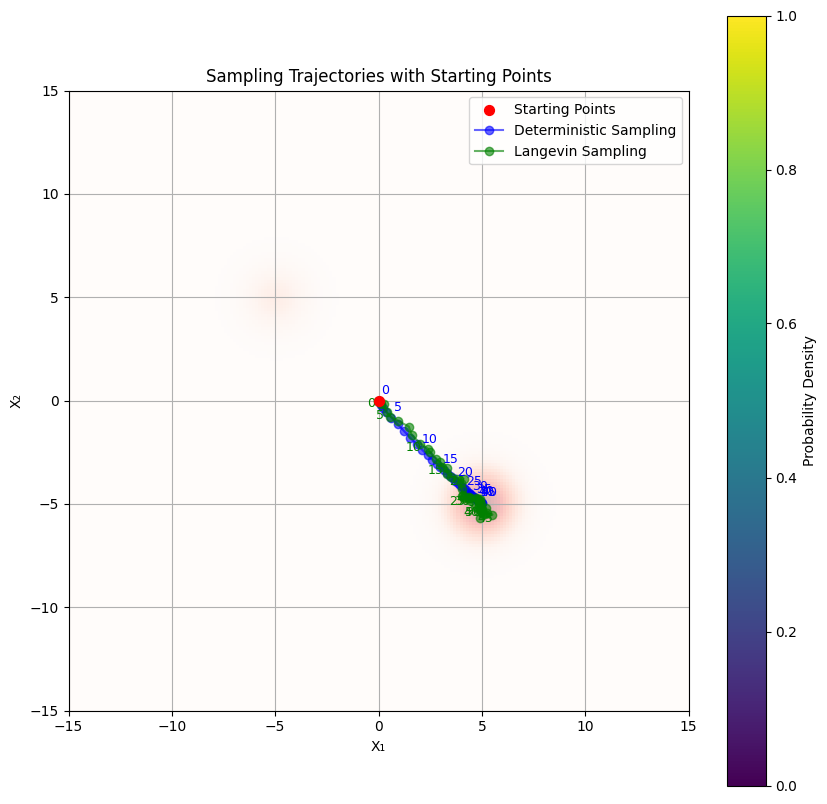

In [ ]:
model = ScoreNet(input_dim=3, hidden_dim=256, num_layers=6)
print(f"Training ScoreNet with fixed sigma=1...")

train_data = torch.tensor(train_samples).float()
dataset = TensorDataset(train_data)
data_loader = DataLoader(dataset, batch_size=256, shuffle=True, num_workers=2)

model, loss_history = train_score_model(
    model,
    data_loader,
    sigma_schedule=None,
    epochs=100,
    learning_rate=0.001,
    scheduler_step=100,
    scheduler_gamma=0.5,
    clip_grad=1.0,
    patience=100,
    fixed_sigma=1,
)

start_points = np.array([[10, 20], [-10, -20], [5, 5], [-5, -5], [0, 0]])
start_points_tensor = torch.tensor(start_points, dtype=torch.float32).to(device)

deterministic_trajectories = []
for start_point in start_points_tensor:
    traj = deterministic_sampling(
        model, start_point.unsqueeze(0), num_steps=50, step_size=0.2
    )
    deterministic_trajectories.append(traj)

langevin_trajectories = []
for start_point in start_points_tensor:
    traj = langevin_sampling(
        model, start_point.unsqueeze(0), num_steps=50, step_size=0.2
    )
    langevin_trajectories.append(traj)

for i, start_point in enumerate(start_points):
    print(f"\nVisualizing Trajectories for Start Point: {start_point}")

    plot_sampling_trajectories_with_start_points(
        start_points=np.array([start_point]),
        deterministic_traj=deterministic_trajectories[i],
        langevin_traj=langevin_trajectories[i],
        z=z,
        extent=extent,
        grid_spacing=5,
    )

## Trajectory Visualization

This cell demonstrates sampling trajectories starting from specific points, showing how deterministic and stochastic sampling methods evolve samples toward the data distribution.

Training Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1000, Loss: 0.066374


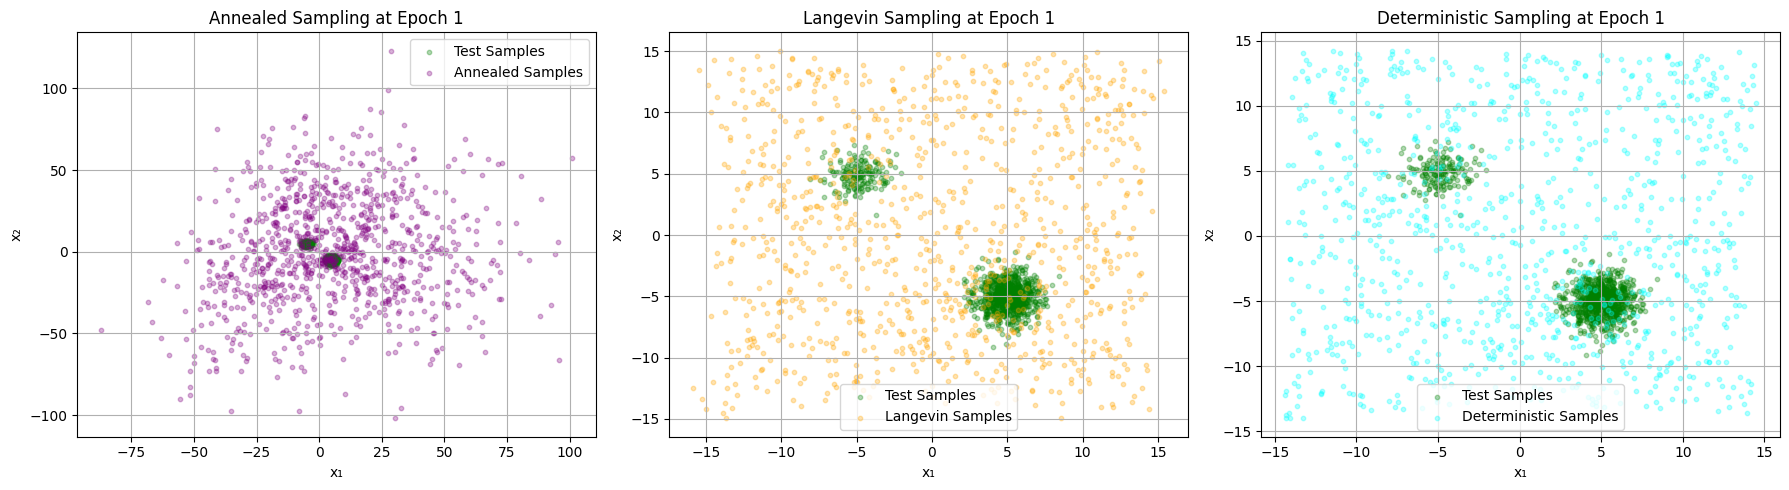

Training Progress:  10%|▉         | 99/1000 [01:20<09:32,  1.57it/s]

Epoch 100/1000, Loss: 0.021640


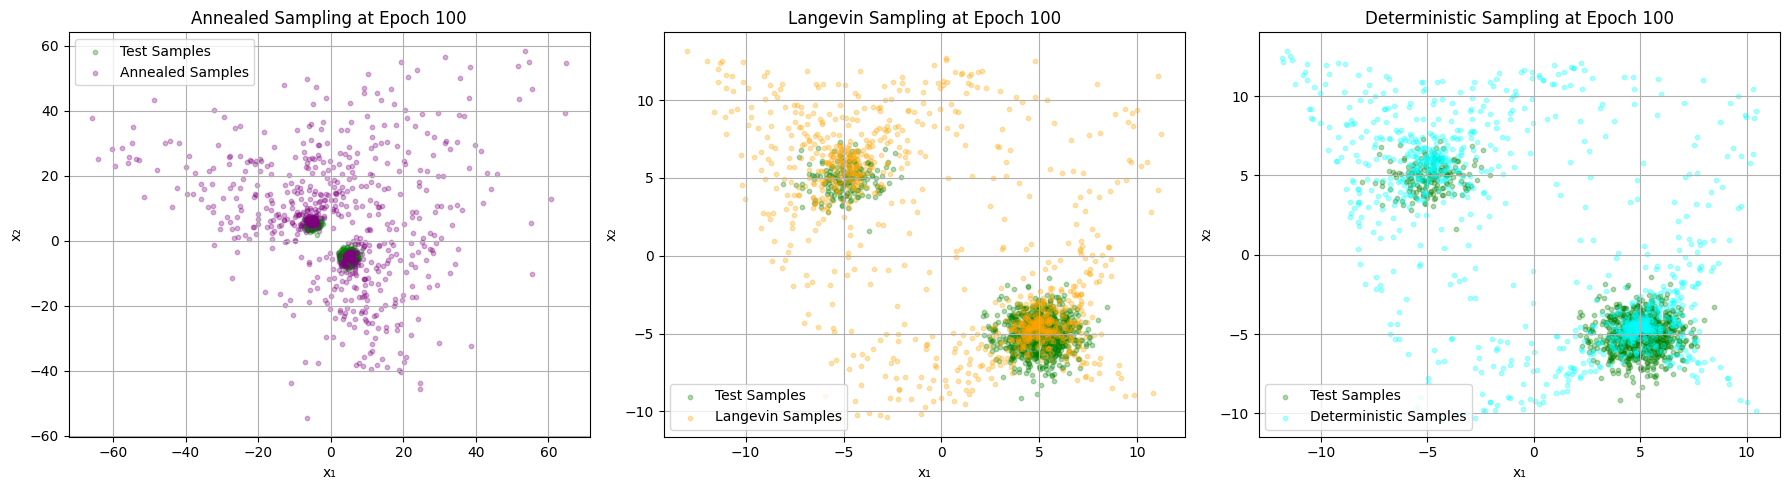

Training Progress:  20%|█▉        | 199/1000 [02:41<08:14,  1.62it/s]

Epoch 200/1000, Loss: 0.017978


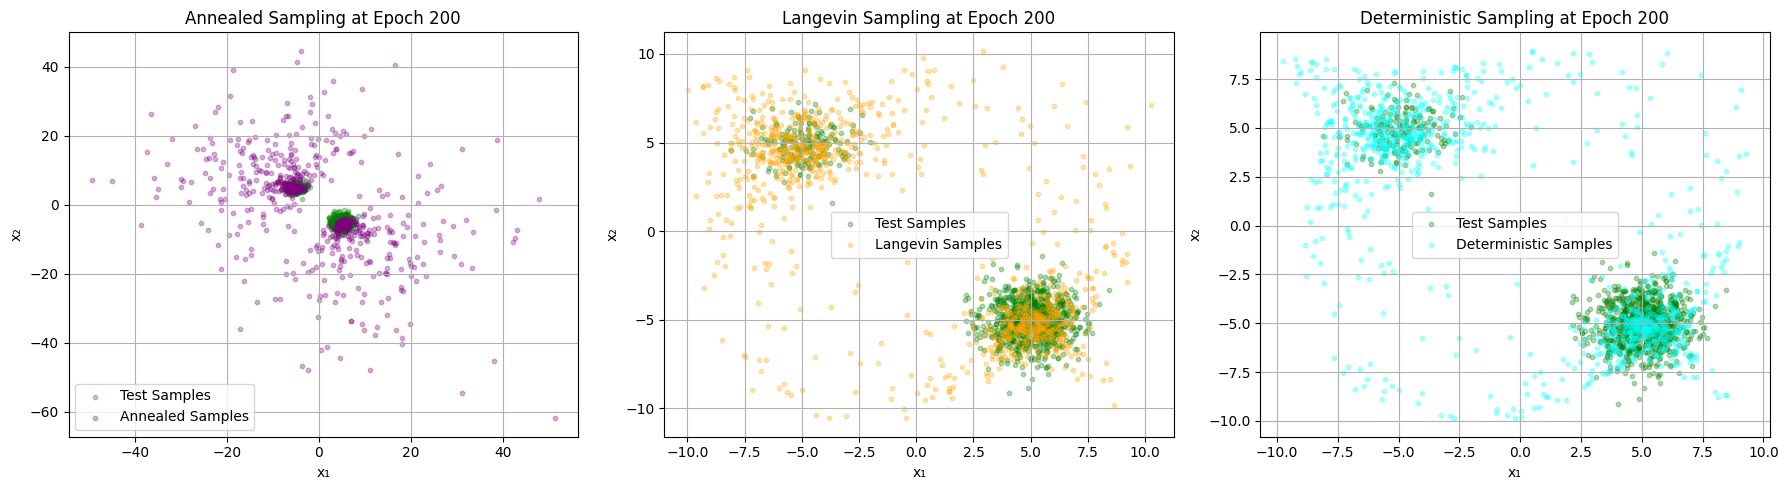

Training Progress:  30%|██▉       | 299/1000 [04:01<07:40,  1.52it/s]

Epoch 300/1000, Loss: 0.020751


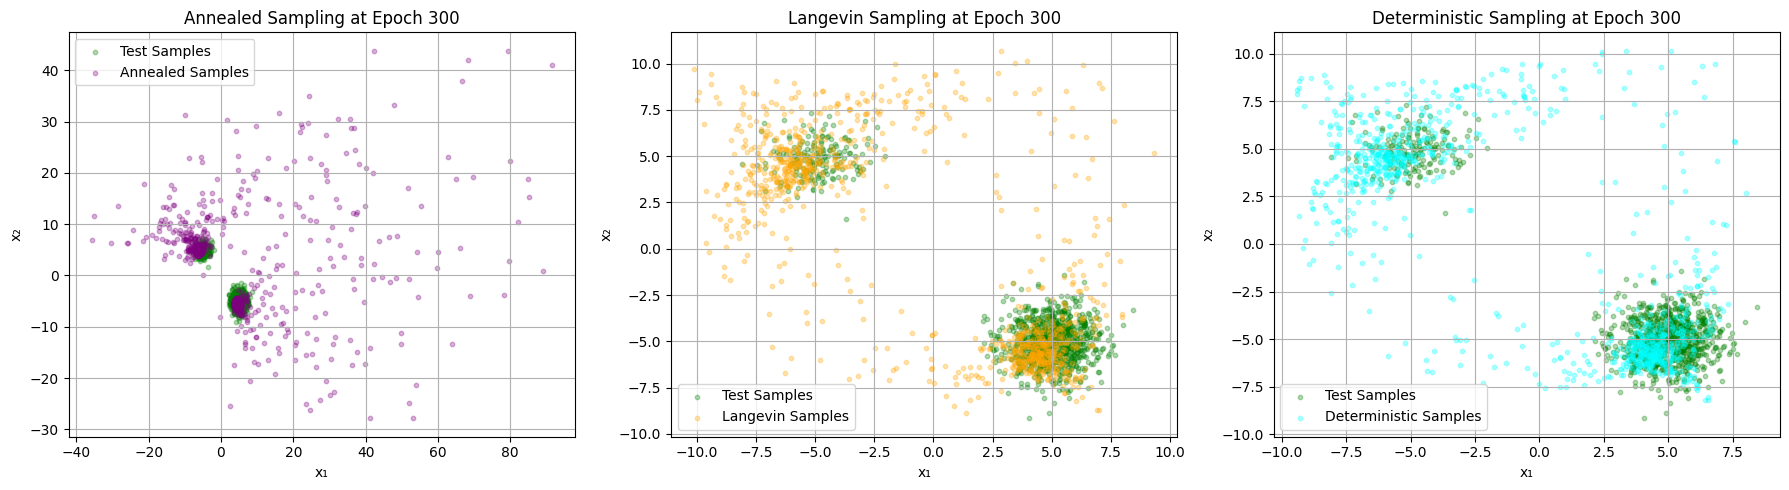

Training Progress:  40%|███▉      | 399/1000 [05:21<08:00,  1.25it/s]

Epoch 400/1000, Loss: 0.017566


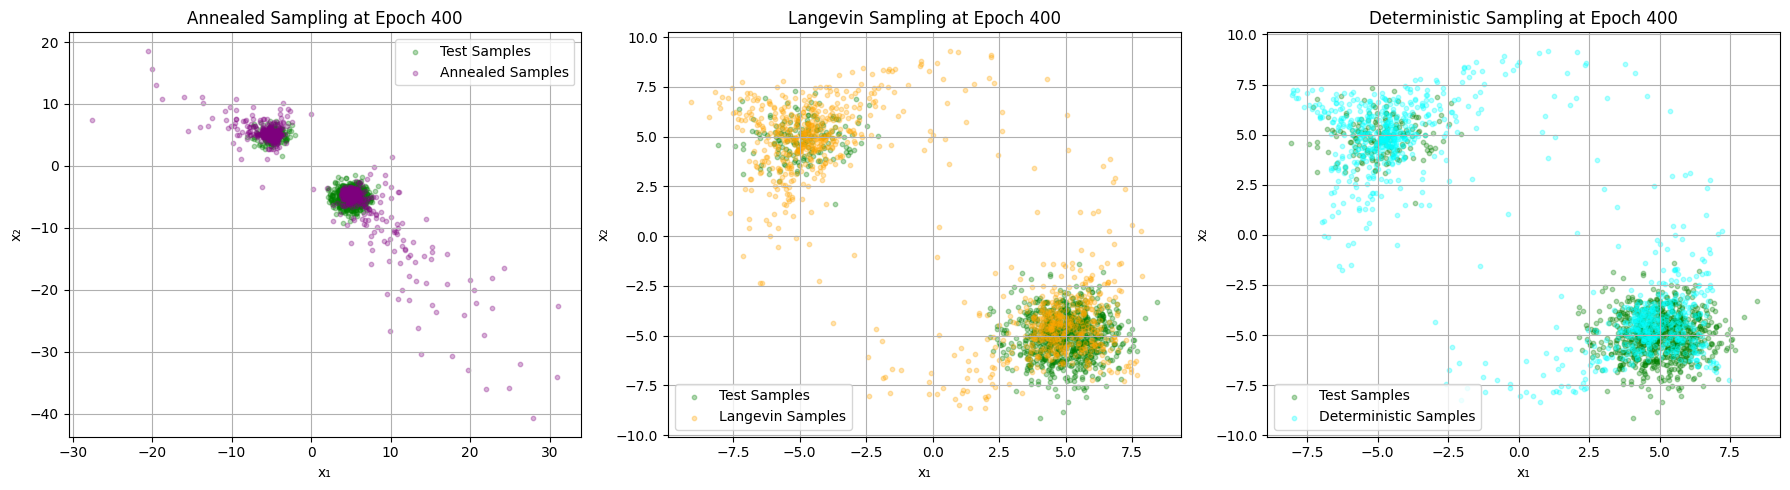

Training Progress:  50%|████▉     | 499/1000 [06:41<06:21,  1.31it/s]

Epoch 500/1000, Loss: 0.020670


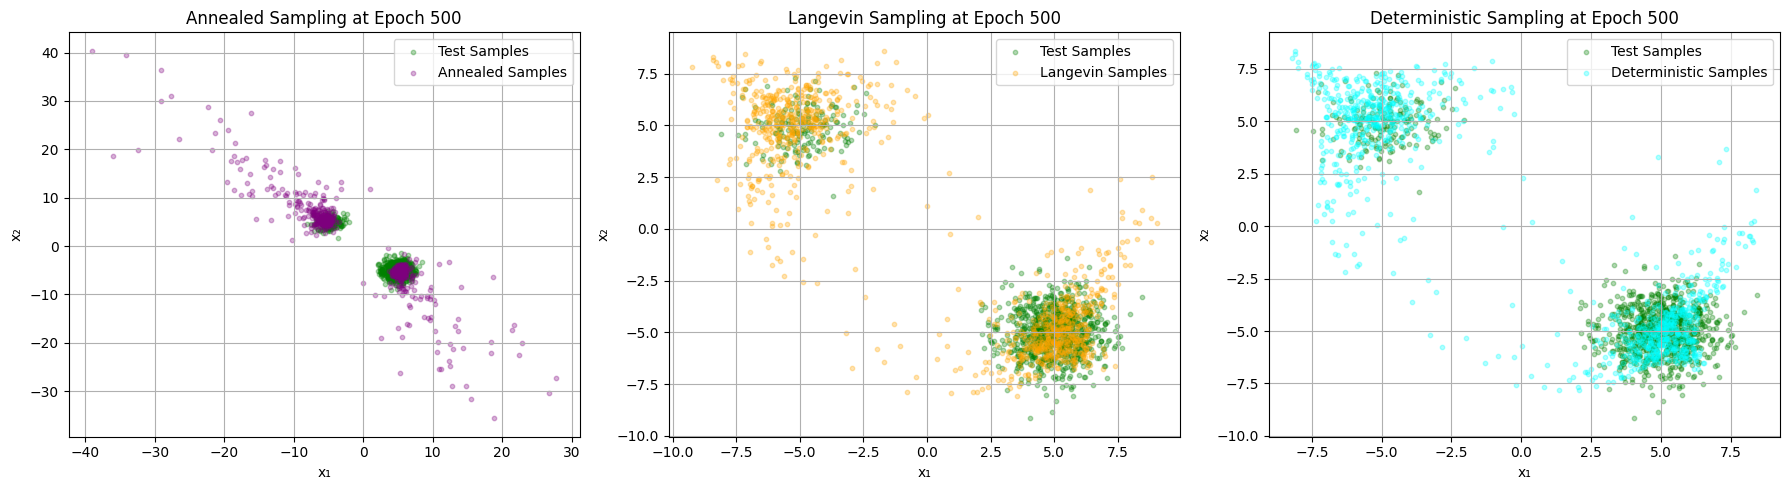

Training Progress:  60%|█████▉    | 599/1000 [08:02<04:19,  1.54it/s]

Epoch 600/1000, Loss: 0.020269


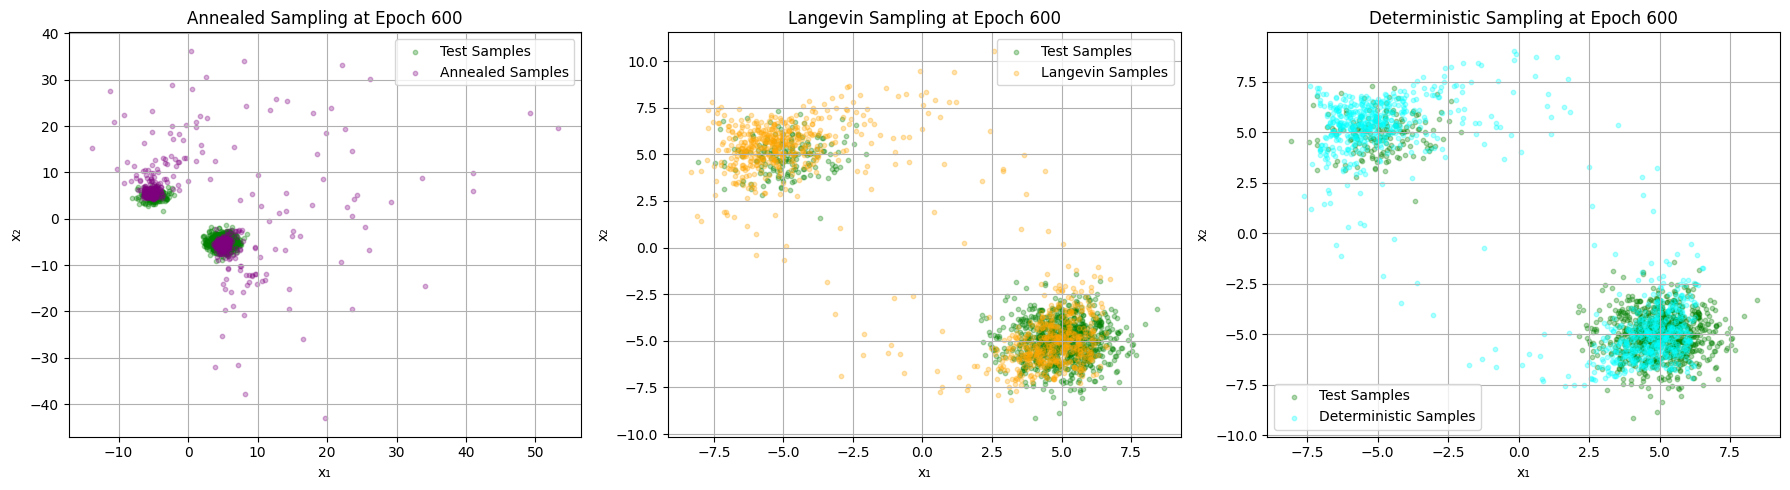

Training Progress:  70%|██████▉   | 699/1000 [10:13<04:10,  1.20it/s]

Epoch 700/1000, Loss: 0.018625


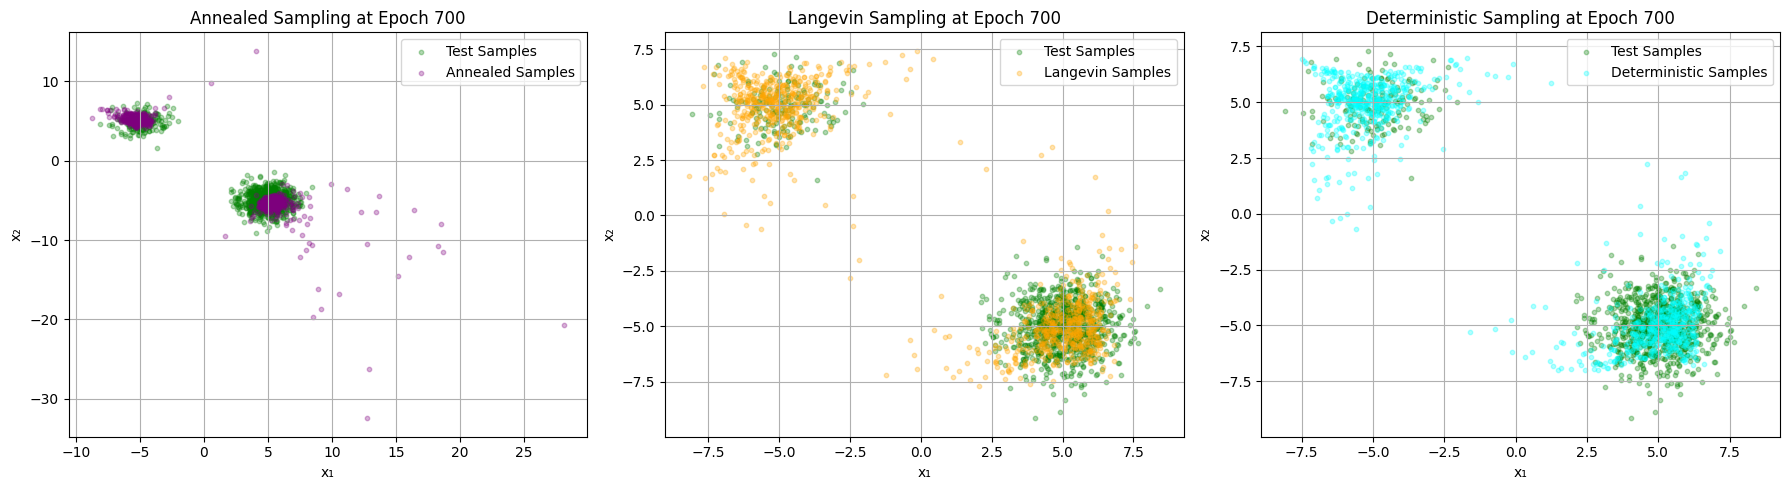

Training Progress:  80%|███████▉  | 799/1000 [11:36<02:31,  1.33it/s]

Epoch 800/1000, Loss: 0.020360


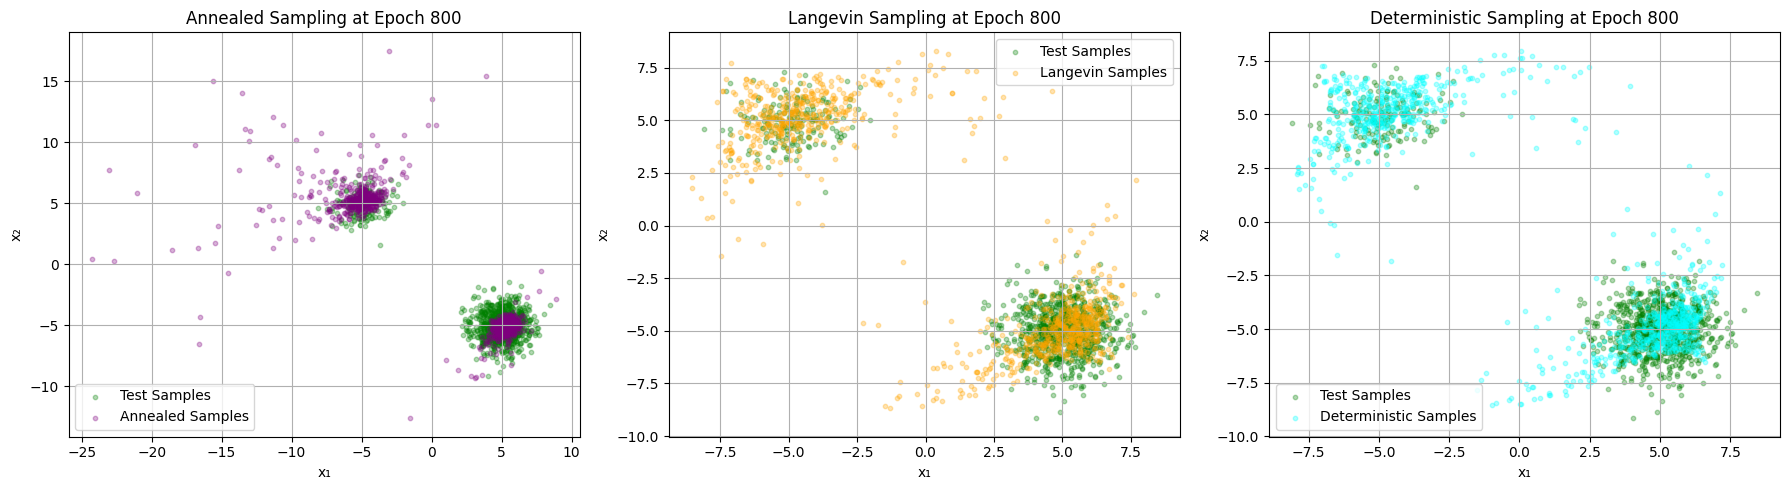

Training Progress:  90%|████████▉ | 899/1000 [12:58<01:11,  1.41it/s]

Epoch 900/1000, Loss: 0.018659


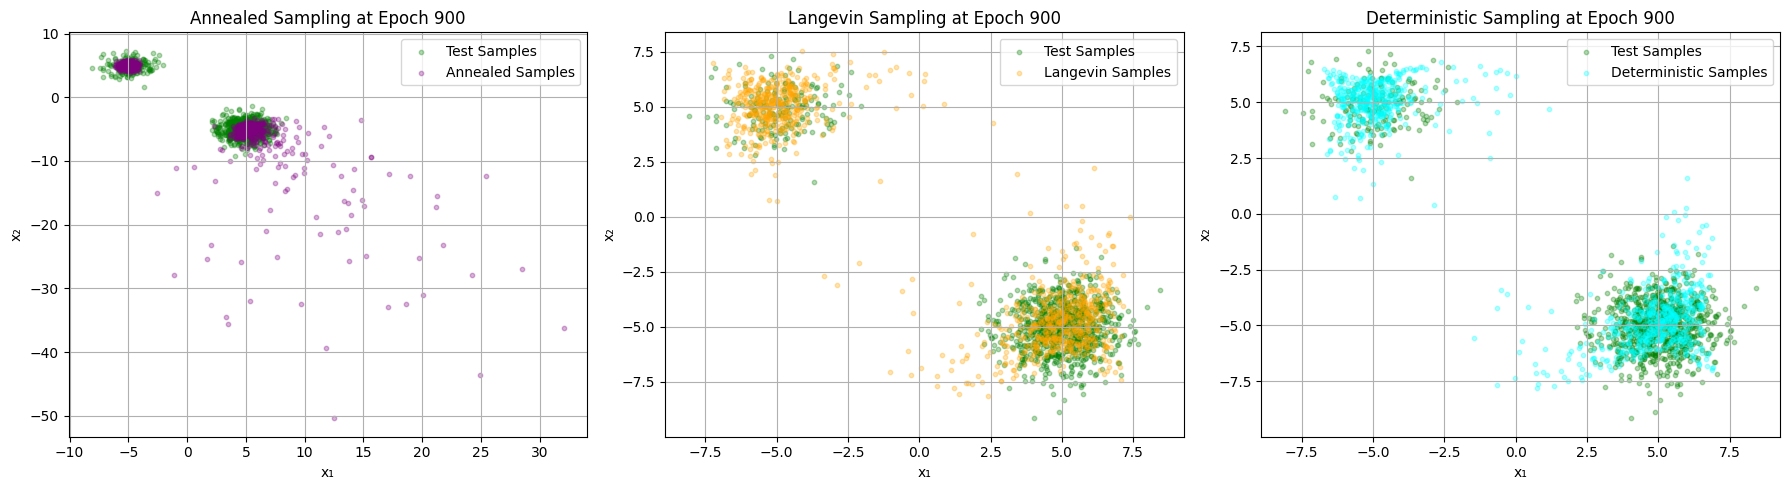

Training Progress: 100%|█████████▉| 999/1000 [14:21<00:00,  1.43it/s]

Epoch 1000/1000, Loss: 0.018004


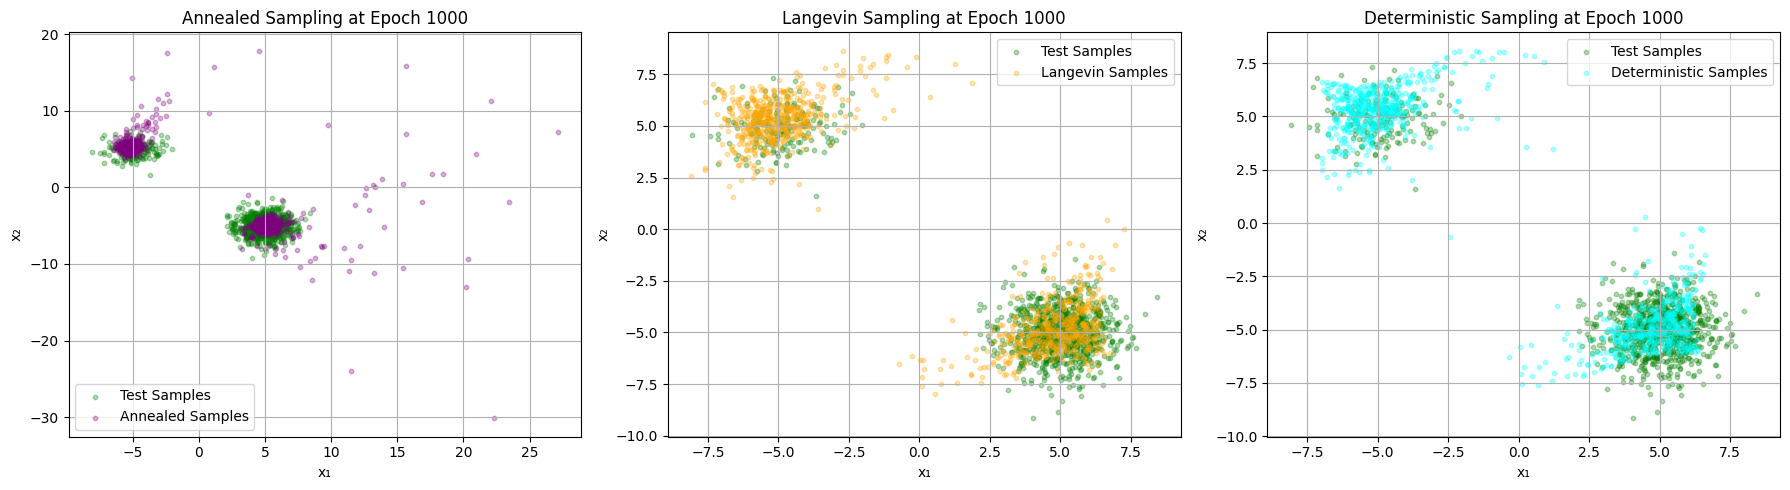

Training Progress: 100%|██████████| 1000/1000 [14:37<00:00,  1.14it/s]
<ipython-input-62-368586b7eaec>:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dic

In [ ]:
epochs = 1000
patience = 200

model_varying_sigma = ScoreNet(input_dim=3, hidden_dim=256, num_layers=6)

train_data = torch.tensor(train_samples).float()
dataset = TensorDataset(train_data)
data_loader = DataLoader(dataset, batch_size=256, shuffle=True, num_workers=2)

model_varying_sigma, loss_history_varying_sigma = train_score_model(
    model=model_varying_sigma,
    data_loader=data_loader,
    sigma_schedule=None,
    epochs=epochs,
    learning_rate=0.001,
    scheduler_step=500,
    scheduler_gamma=0.5,
    clip_grad=1.0,
    patience=patience,
    fixed_sigma=None,
)

## Varying Sigma Training

This cell trains a score network with varying noise levels during training, allowing it to learn scores across different scales for more robust generation.